In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer

In [2]:

newsgroups = fetch_20newsgroups(
    subset='train',
    remove=('headers', 'footers', 'quotes')
)

documents = newsgroups.data

print("Number of documents:", len(documents))

Number of documents: 11314


In [3]:
vectorizer = CountVectorizer(
    stop_words='english',
    max_features=5000
)

X = vectorizer.fit_transform(documents)

vocabulary = vectorizer.get_feature_names_out()

print("Vocabulary size:", len(vocabulary))

Vocabulary size: 5000


In [4]:
word_counts = np.asarray(X.sum(axis=0)).flatten()

print("Total words:", word_counts.sum())

Total words: 885959


In [5]:
theta_mle = word_counts / word_counts.sum()

In [6]:
print(theta_mle.sum())

1.0


In [7]:
def map_estimate(counts, alpha):

    counts = np.asarray(counts)

    numerator = counts + alpha - 1

    numerator = np.maximum(numerator, 0)

    theta = numerator / numerator.sum()

    return theta

In [8]:
alphas = [1, 1.5, 2, 10]

map_results = {}

for a in alphas:
    map_results[a] = map_estimate(word_counts, a)

In [9]:
print("Word\tMLE")

for i in range(10):
    print(vocabulary[i], theta_mle[i])

print("\nMAP Estimates")

for a in alphas:

    print("\nAlpha =", a)

    for i in range(10):
        print(vocabulary[i], map_results[a][i])

Word	MLE
00 0.0013589793658623029
000 0.0007822032396533023
01 0.00025734825200714705
02 0.0002957247457275111
03 0.00023816000514696503
04 0.0003927947004319613
040 4.7406256948684985e-05
05 0.00019188246860182018
06 0.00018285270537349922
07 8.578275066904902e-05

MAP Estimates

Alpha = 1
00 0.0013589793658623029
000 0.0007822032396533023
01 0.00025734825200714705
02 0.0002957247457275111
03 0.00023816000514696503
04 0.0003927947004319613
040 4.7406256948684985e-05
05 0.00019188246860182018
06 0.00018285270537349922
07 8.578275066904902e-05

Alpha = 1.5
00 0.0013557181591947406
000 0.000780565000748487
01 0.00025718688200581004
02 0.0002954553896128015
03 0.00023805262820231435
04 0.00039225220297166215
040 4.783563450873929e-05
05 0.0001919053102056482
06 0.0001829009554745914
07 8.610414211573072e-05

Alpha = 2
00 0.0013524752541923927
000 0.000778935955526573
01 0.0002570264176017078
02 0.0002951875451058915
03 0.00023794585384961597
04 0.000391712749969415
040 4.826260243176173e-

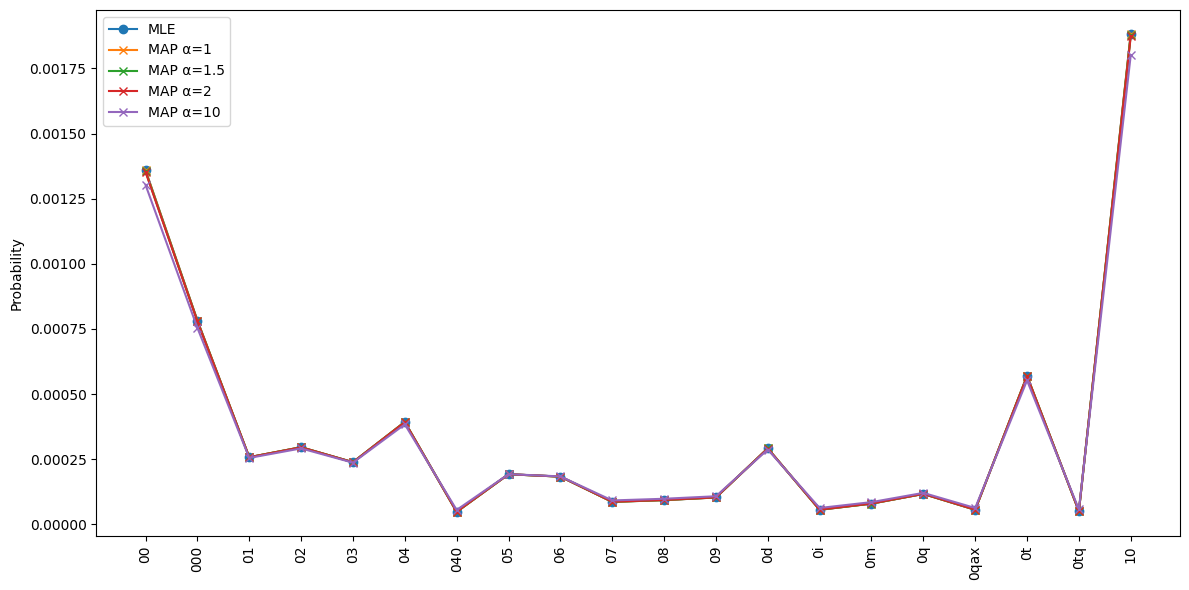

In [10]:
indices = np.arange(20)

plt.figure(figsize=(12,6))

plt.plot(indices,
         theta_mle[:20],
         marker='o',
         label='MLE')

for a in alphas:
    plt.plot(indices,
             map_results[a][:20],
             marker='x',
             label=f"MAP α={a}")

plt.xticks(indices,
           vocabulary[:20],
           rotation=90)

plt.ylabel("Probability")

plt.legend()

plt.tight_layout()

plt.show()

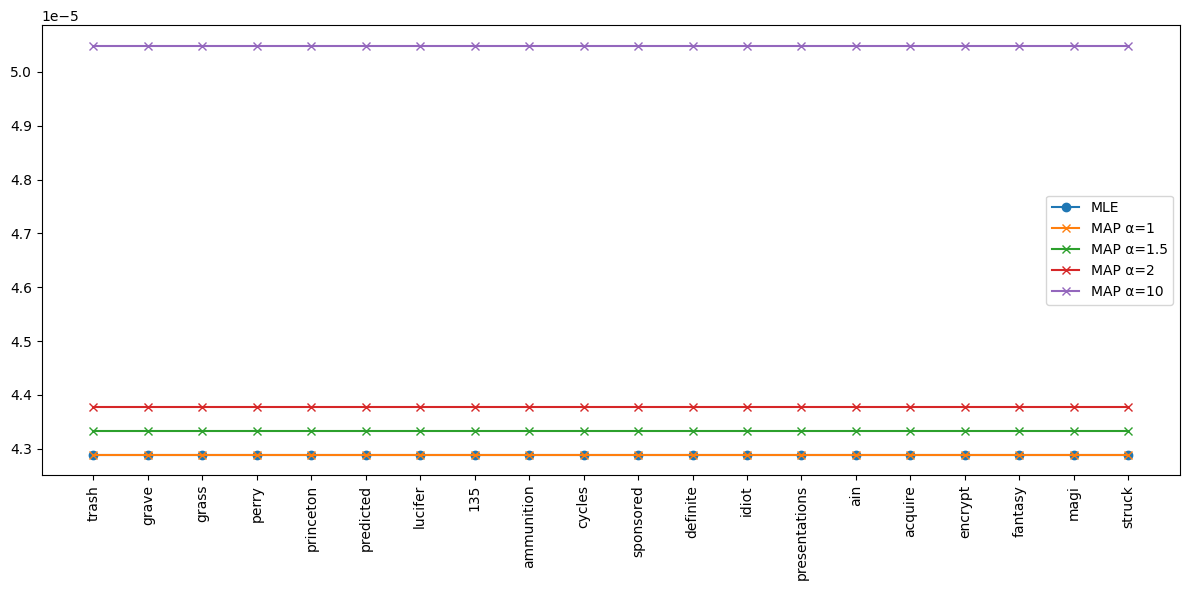

In [11]:
rare_indices = np.argsort(word_counts)[:20]

plt.figure(figsize=(12,6))

plt.plot(theta_mle[rare_indices],
         label="MLE",
         marker='o')

for a in alphas:
    plt.plot(map_results[a][rare_indices],
             marker='x',
             label=f"MAP α={a}")

plt.xticks(range(20),
           vocabulary[rare_indices],
           rotation=90)

plt.legend()

plt.tight_layout()

plt.show()